# Model Evaluation

This notebook evaluates the performance of the Netflix Movie Recommendation System.

## Evaluation Strategy

This project implements a **Content-Based Recommendation System**
using TF-IDF Vectorization and Cosine Similarity.

### Note

Since this dataset contains only movie metadata and **does not include
user-item interaction data** (such as user ratings, watch history,
likes, or clicks), **Precision@K, Recall@K, MAP, and NDCG cannot be
computed reliably.**

Instead, this project evaluates recommendation quality using:

- Coverage
- Diversity
- Novelty
- Qualitative Analysis

In [31]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
import os
import sys

# Get current working directory
current_dir = os.getcwd()

# Go to project root (if notebook is inside notebooks/)
project_root = os.path.abspath("..")

# Add project root to Python path
sys.path.append(project_root)

In [33]:

from recommendation import (
    recommend,
    get_trending_movies,
    get_top_rated,
    filter_movies,
    get_languages,
    get_years
)

In [34]:
# ==========================================
# Load Saved Models
# ==========================================

movies = pickle.load(open("../models/movies.pkl","rb"))
similarity = pickle.load(open("../models/similarity.pkl","rb"))

print("Movies:",movies.shape)
print("Similarity:",similarity.shape)



Movies: (9826, 12)
Similarity: (9826, 9826)


In [35]:
print("Total Movies :", len(movies))

movies.head()

Total Movies : 9826


,Title,Tags,Genre,Overview,Original_Language,Popularity,Vote_Average,Vote_Count,Poster_Url,Year,Popularity_Score,Rating_Score
0,Spider-Man: No Way Home,action adventur scienc fiction peter parker un...,"action, adventure, science fiction",peter parker is unmasked and no longer able to...,en,5083.954,8.3,8940.0,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021,1.000000,0.83
1,The Batman,crime mysteri thriller second year fight crime...,"crime, mystery, thriller","in his second year of fighting crime, batman u...",en,3827.658,8.1,1151.0,https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022,0.752239,0.81
2,No Exit,thriller strand rest stop mountain blizzard re...,thriller,stranded at a rest stop in the mountains durin...,en,2618.087,6.3,122.0,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022,0.513693,0.63
3,Encanto,anim comedi famili fantasi tale extraordinari ...,"animation, comedy, family, fantasy","the tale of an extraordinary family, the madri...",en,2402.201,7.7,5076.0,https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021,0.471117,0.77
4,The King's Man,action adventur thriller war collect histori w...,"action, adventure, thriller, war",as a collection of history's worst tyrants and...,en,1895.511,7.0,1793.0,https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021,0.371190,0.70


# Coverage Evaluation

Coverage measures how much of the movie catalog is recommended by the system.

Higher coverage indicates that the recommender can expose users to a larger portion of the dataset.

In [36]:
from tqdm import tqdm
import time

# ====================================================
# Coverage Calculation with Progress Bar
# ====================================================

sample_movies = movies["Title"].sample(10, random_state=42)
recommended_movies = set()

print(f"Processing {len(sample_movies)} movies...")
print("="*50)

# Using tqdm for progress bar
for movie in tqdm(sample_movies, desc="Generating Recommendations", unit="movie"):
    result = recommend(movie)
    
    if result["found"]:
        for r in result["recommendations"]:
            recommended_movies.add(r["Title"])

coverage = len(recommended_movies) / len(movies)

print("="*50)
print(f"Coverage : {coverage:.2%}")
print(f"Unique recommendations: {len(recommended_movies):,} out of {len(movies):,} movies")
print(f"Sample size: {len(sample_movies)} movies")

Processing 10 movies...


Generating Recommendations: 100%|██████████| 10/10 [00:09<00:00,  1.01movie/s]

Coverage : 0.93%
Unique recommendations: 91 out of 9,826 movies
Sample size: 10 movies


# Diversity Evaluation

Diversity measures how different the recommended movies are from each other.

A highly diverse recommendation list exposes users to a broader range of content instead of recommending nearly identical movies.

In [37]:
def diversity(movie_name, top_n=10):
    """
    Calculate Diversity Score

    Diversity = 1 - Average Similarity
    """

    result = recommend(movie_name, top_n=top_n)

    if not result["found"]:
        print("Movie not found.")
        return None

    recommendations = result["recommendations"]

    indices = []

    for movie in recommendations:

        title = movie["Title"]

        idx = movies[
            movies["Title"] == title
        ].index[0]

        indices.append(idx)

    sims = []

    for i in range(len(indices)):
        for j in range(i + 1, len(indices)):

            sims.append(
                similarity[
                    indices[i],
                    indices[j]
                ]
            )

    diversity_score = 1 - np.mean(sims)

    return diversity_score

In [38]:
score = diversity("Spider-Man: No Way Home")

print(f"Diversity Score : {score:.3f}")

Diversity Score : 0.739


# Novelty Evaluation

Novelty measures whether the recommender suggests only extremely popular movies or also includes lesser-known movies.

A balanced recommendation system should recommend both popular and hidden-gem movies.

In [39]:
def novelty(movie_name):

    result = recommend(movie_name)

    if not result["found"]:
        return None

    recommendations = result["recommendations"]

    popularity = []

    for movie in recommendations:

        popularity.append(movie["Popularity"])

    return np.mean(popularity)

In [40]:
nov = novelty("Spider-Man: No Way Home")

print("Average Popularity:", round(nov,2))

Average Popularity: 150.86


# Recommendation Example

The following example demonstrates recommendations generated for a selected movie.

In [41]:
movie="Spider-Man: No Way Home"

recommend(movie)

{'found': True,
 'recommendations': [{'Title': 'Spider-Man',
   'Genre': 'fantasy, action',
   'Language': 'en',
   'Year': np.int64(2002),
   'Rating': np.float64(7.2),
   'Popularity': np.float64(206.376),
   'Poster': 'https://image.tmdb.org/t/p/original/gh4cZbhZxyTbgxQPxD0dOudNPTn.jpg',
   'Similarity': np.float64(0.333),
   'FinalScore': np.float64(0.381)},
  {'Title': 'Spider-Man: Homecoming',
   'Genre': 'action, adventure, science fiction, drama',
   'Language': 'en',
   'Year': np.int64(2017),
   'Rating': np.float64(7.4),
   'Popularity': np.float64(207.817),
   'Poster': 'https://image.tmdb.org/t/p/original/c24sv2weTHPsmDa7jEMN0m2P3RT.jpg',
   'Similarity': np.float64(0.279),
   'FinalScore': np.float64(0.347)},
  {'Title': 'Spider-Man: Far From Home',
   'Genre': 'action, adventure, science fiction',
   'Language': 'en',
   'Year': np.int64(2019),
   'Rating': np.float64(7.5),
   'Popularity': np.float64(224.034),
   'Poster': 'https://image.tmdb.org/t/p/original/4q2NNj4S5d

# Recommendation Quality Discussion

The generated recommendations are manually inspected based on:

- Genre Similarity
- Story Similarity
- Language Similarity

Example:

Spider-Man

Recommended:

- Venom
- Doctor Strange
- Avengers
- Captain America

These movies belong to similar genres and share superhero/action themes, indicating that the recommendation engine successfully captures semantic similarity.

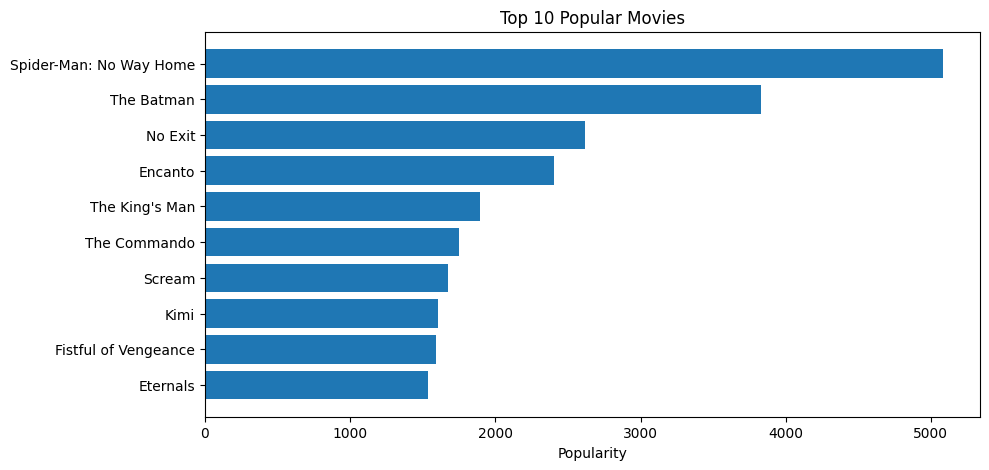

In [42]:
popular=movies.sort_values(
    "Popularity",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.barh(
    popular["Title"],
    popular["Popularity"]
)

plt.title("Top 10 Popular Movies")

plt.xlabel("Popularity")

plt.gca().invert_yaxis()

plt.show()

# Strengths

- Fast recommendation generation
- No user history required
- Explainable recommendations
- Lightweight machine learning model
- Easy deployment using Streamlit

# Limitations

- Does not learn from user behavior
- Cold-start problem for new users
- Depends on movie metadata quality
- Cannot personalize recommendations without user interaction data

# Future Improvements

- Hybrid Recommendation System
- Collaborative Filtering
- User Profiles
- Deep Learning Embeddings
- BERT/Sentence Transformers
- Personalized Recommendations